In [1]:
# illustrative example of use VeraRubin 

## Creating a Local Butler for a Selected Set of Visits

> Version: 1.0
> Container Size: Large

> Description: In this notebook, we present illustrative examples of using Vera Rubin’s functions to create a local Butler for a chosen set of visits

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

Release r29.2.0 (RSP Build 2244)
lsst_distrib          gc675d380bf+f75de59d28 	current o_latest v29_2_0 v29_2_0_rc1 setup


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import VeraRubin as vr
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler

In [5]:
#vr._run(['butler', 'transfer-datasets', 'https://data.lsst.cloud/api/butler/repo/dp1/', './local_butler5', 
#         '--where', "instrument='LSSTComCam' AND visit IN (2024113000172) AND band='u'", 
#         '--collections', 'LSSTComCam/DP1', '--dataset-type', 'deep_coadd'])

### Load the butler and show some information

In [6]:
# Initialize Butler
collection = "LSSTComCam/DP1"
repository = "dp1"

butler = Butler(config=repository, collections=collection)
# vr.ExpButler(repository=repository, collections=collection, info=False)._create_butler()

assert butler is not None

In [7]:
registry = butler.registry
dt_list = registry.queryDatasetTypes()  # datasetTypes
dt_collections = registry.queryCollections()  # collections

In [8]:
# Base Collection we want to used

collection_targets = [t.lower() for t in ["LSSTComCam/DP1", "skymaps", "LSSTComCam/raw"]]

print(f'Found {len(dt_collections)} Collections \n')
grouped_collections = {key: [] for key in collection_targets} # Dictionary to store matches grouped by category

for dt in dt_collections:
    name = dt.lower()
    for collection in collection_targets:
        if collection in name:
            grouped_collections[collection].append(dt)

# Display grouped results
print("Related Collections by Category \n")

for collection in collection_targets:
    print(f"Category: {collection}")
    if grouped_collections[collection]:
        for item in sorted(grouped_collections[collection]):
            print(f"  - {item}")
    else:
        print("  (none found)")
    print()

Found 95 Collections 

Related Collections by Category 

Category: lsstcomcam/dp1
  - LSSTComCam/DP1
  - LSSTComCam/DP1/v1
  - LSSTComCam/DP1/v2

Category: skymaps
  - skymaps

Category: lsstcomcam/raw
  - LSSTComCam/raw/DP1-RC2/DM-49594
  - LSSTComCam/raw/all



In [9]:
# Base datasetTypes we want to search

base_targets = [t.lower() for t in ["visit_image", "cal_exp", "calexp", "deep_coadd", "deepcoadd", "raw", "Warp"]]

print(f'Found {len(dt_list)} DatasetTypes \n')
grouped = {key: [] for key in base_targets}

for dt in dt_list:  # Scan through all datasetTypes
    name = dt.name.lower()
    for base in base_targets:  # Check if the datasetType name contains any of the base targets
        if base in name:
            grouped[base].append(dt.name)

print("Related DatasetTypes by Category \n")
for base in base_targets:
    print(f"Category: {base}")
    if grouped[base]:
        for item in sorted(grouped[base]):
            print(f"  - {item}")
    else:
        print("  (none found)")
    print()

Found 592 DatasetTypes 

Related DatasetTypes by Category 

Category: visit_image
  - visit_image
  - visit_image_background

Category: cal_exp
  (none found)

Category: calexp
  (none found)

Category: deep_coadd
  - deep_coadd
  - deep_coadd_background
  - deep_coadd_n_image

Category: deepcoadd
  - assembleDeepCoadd_config
  - assembleDeepCoadd_gatherResourceUsage_config
  - assembleDeepCoadd_gatherResourceUsage_log
  - assembleDeepCoadd_gatherResourceUsage_metadata
  - assembleDeepCoadd_log
  - assembleDeepCoadd_metadata
  - deepCoadd_dcr_ddec_consolidated_map_weighted_mean
  - deepCoadd_dcr_dra_consolidated_map_weighted_mean
  - deepCoadd_dcr_e1_consolidated_map_weighted_mean
  - deepCoadd_dcr_e2_consolidated_map_weighted_mean
  - deepCoadd_epoch_consolidated_map_max
  - deepCoadd_epoch_consolidated_map_mean
  - deepCoadd_epoch_consolidated_map_min
  - deepCoadd_exposure_time_consolidated_map_sum
  - deepCoadd_psf_e1_consolidated_map_weighted_mean
  - deepCoadd_psf_e2_consolidated

## Identify visit images around location

In [10]:
# Identify visit images around location
ra_deg, dec_deg = (53.2, -27.8)
loc_data = ra_deg, dec_deg
#bands = ['u', 'r', 'i']
bands = ['u', 'i']

visit_name = base_targets[0]
print(f"Using -> {visit_name}")

visits_image_selected_list = {}
for band in bands:
    visit_refs = vr.visit_dataset(butler, band, loc_data, use_patch_area=False, detectors=None, timespan=None, visit_ids=None)
    print(f'[INF] Found {len(visit_refs)} visits in band {band}')
    visits_image_selected_list[band] = visit_refs  # Saving the visit data set per band

Using -> visit_image
[INF] Found 31 visits in band u
[INF] Found 114 visits in band i


In [12]:
# Data example
print(visits_image_selected_list['u'][0].dataId) # datasetType dimensions run dataId
print(visits_image_selected_list['u'][1].dataId) # datasetType dimensions run dataId

{instrument: 'LSSTComCam', detector: 2, visit: 2024110900195, band: 'u', day_obs: 20241109, physical_filter: 'u_02'}
{instrument: 'LSSTComCam', detector: 5, visit: 2024110900198, band: 'u', day_obs: 20241109, physical_filter: 'u_02'}


### Selecting the visits from *visit_image*

Sorting the *visit_image* visits by their quality

> [IMPORTANT]: The final version used the Alma filters

In [13]:
visits_selected_sort_list = {}
for band, visit_calexp_dataset in visits_image_selected_list.items():
    snr_list, valid_refs = [], []
    n_visits = len(visit_calexp_dataset)
    
    for k, ref in enumerate(visit_calexp_dataset):
        vr.progressbar(k, n_visits-1)
        try:
            exp = butler.get(visit_name, dataId=(ref.dataId))
            snr = vr.measure_quality(exp)
            
            snr_list.append(snr)
            valid_refs.append(ref)
            del exp  # free memory early
        except Exception as e:
            print(f"[ERROR] Could not load exposure {ref.dataId}: {e}")

    # Sort by SNR
    if len(snr_list) == 0:
        print(f"[WARNING] No valid exposures for band {band}")
        visits_selected_sort_list[band] = []
        getWcs_selected_sort_list[band] = []
        continue
    
    # Sort by SNR
    sorter_snr = np.argsort(snr_list)[::-1]  # descending
    visits_selected_sort_list[band] = [valid_refs[i] for i in sorter_snr]

Progress: [####################] 100%
Progress: [####################] 100%


In [14]:
# taking the first four with best quality
nbest = 4

visits_u = visits_selected_sort_list['u'][:nbest]
visits_i = visits_selected_sort_list['i'][:nbest]

### Creating the local butler repository and copying the visits

In [15]:
# General CONFIGURATION
LOCAL_REPO = "./local_butler"       # Local butler repo path
REMOTE_REPO = vr.get_butler_location(butler)  # Remote butler repo path

In [16]:
# Making a local butler repo and copying the visits_u
vr.main_local_repo(
    LOCAL_REPO, 
    REMOTE_REPO,
    visits_datasetRef=visits_u,
    remote_collection="LSSTComCam/DP1",
    LOGDIR="local_butler/logs_u",
    chain_name="local_main_chain",
    make_repo=True)

2026-02-18 03:59:11 [INFO] Created LOGDIR at local_butler/logs_u


2026-02-18 03:59:11 [INFO] Starting pipeline for local repo: ./local_butler


2026-02-18 03:59:11 [INFO] Creating empty repo at ./local_butler


2026-02-18 03:59:11 [INFO] Creating Butler repo at ./local_butler


2026-02-18 03:59:12 [INFO] Empty repo created successfully.


...

2026-02-18 04:00:30 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-02-18 04:00:30 [INFO] Registered CHAINED collection: local_main_chain


2026-02-18 04:00:30 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-02-18 04:00:30 [INFO] Pipeline finished successfully.


True

### Visualizing some repo information

In [18]:
#from lsst.daf.butler import Butler
lbutler = Butler(LOCAL_REPO) #, writeable=True)

In [19]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
skymaps                                                     RUN    


In [20]:
# Dataset types
print("List of valaibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of valaibles datasetType:
     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [21]:
!butler query-datasets $LOCAL_REPO skyMap \
  --collections skymaps


 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [22]:
!butler query-dimension-records $LOCAL_REPO 'tract'

    skymap     id   region 
------------- ---- --------
lsst_cells_v1 4848 (elided)
lsst_cells_v1 4849 (elided)
lsst_cells_v1 5063 (elided)
lsst_cells_v1 5064 (elided)


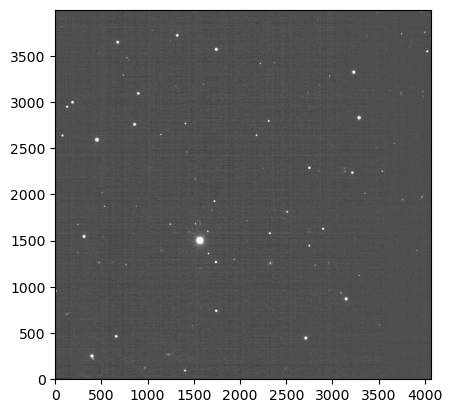

In [32]:
# visualizating 

id_visit = {'instrument': 'LSSTComCam', 'detector': 0,
            'visit': 2024113000175, 'band': 'u', 
            'day_obs': 20241130, 'physical_filter': 'u_02'} 

img = lbutler.get('visit_image', dataId=id_visit, # visits_u[0].dataId, 
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)

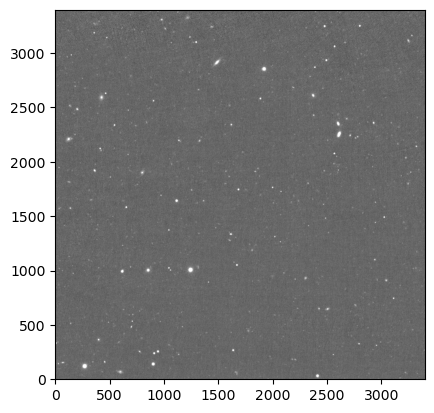

In [39]:
loc_data = ra_deg, dec_deg
tract, patch = vr.tract_patch(butler, ra_deg, dec_deg)
dataId = {"skymap": "lsst_cells_v1", "visit": 2024113000175, "band": "u", 'physical_filter': 'u_02', "tract": tract, 
          "patch": patch,}

img = lbutler.get('deep_coadd', dataId=dataId, # visits_u[0].dataId, 
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)

### Adding to the local repo,the i-band

In [40]:
vr.main_local_repo(
    LOCAL_REPO, 
    REMOTE_REPO,
    visits_datasetRef=visits_i,
    remote_collection="LSSTComCam/DP1",
    LOGDIR="local_butler/logs_u",
    chain_name="local_main_chain",
    make_repo=False)

2026-02-18 04:15:56 [INFO] Created LOGDIR at local_butler/logs_u


2026-02-18 04:15:56 [INFO] Starting pipeline for local repo: ./local_butler


2026-02-18 04:15:56 [INFO] Registering instruments: ['LSSTComCam']


2026-02-18 04:15:56 [INFO] Detected instruments to register: ['LSSTComCam']


2026-02-18 04:15:56 [INFO] Opening remote Butler: https://data.lsst.cloud/api/butler/repo/dp1/ (collections=LSSTComCam/DP1)


...

2026-02-18 04:17:08 [INFO] Making a chained collection


2026-02-18 04:17:08 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-02-18 04:17:08 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-02-18 04:17:08 [INFO] Pipeline finished successfully.


True

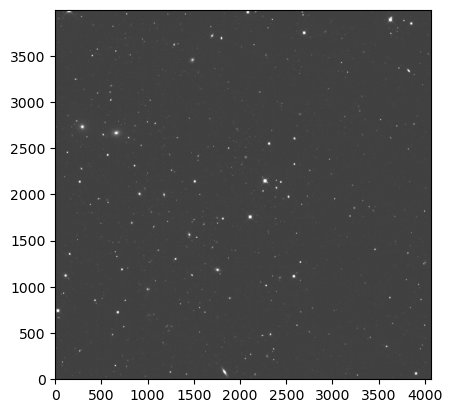

In [42]:
# visualizating 

id_visit = {'instrument': 'LSSTComCam', 'detector': 5,
            'visit': 2024110800303, 'band': 'i', 
            'day_obs': 20241108, 'physical_filter': 'i_06'}

img = lbutler.get('visit_image', dataId=id_visit, #visits_i[-1].dataId,
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)

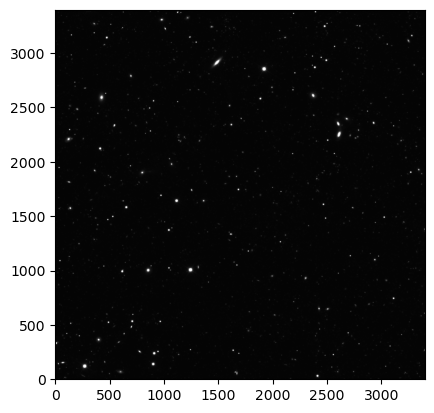

In [43]:
loc_data = ra_deg, dec_deg
tract, patch = vr.tract_patch(butler, ra_deg, dec_deg)
dataId = {"skymap": "lsst_cells_v1", "visit": 2024110800303, "band": "i", 'physical_filter': 'u_02', "tract": tract, 
          "patch": patch,}

img = lbutler.get('deep_coadd', dataId=dataId, # visits_u[0].dataId, 
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)